# Tarea: Uso de Funciones en Python (Bioquímica)

### Objetivo: 
-Crear funciones propias
-Usar parámetros y return
-Evitar repetir código
-Organizar mejor el notebook

### ***Datos***

In [39]:
glucosa=[82, 95, 110, 130, 88, 76, 145, 99, 102, 118, 90, 104, 127, 140, 85]
hba1c=[5.1, 5.4, 5.9, 6.7, 5.2, 5.0, 7.2, 5.5, 5.8, 6.1, 5.3, 5.9, 6.6, 7.0, 5.1]

## Parte 1 - Función de estadísticas básicas

**Función y retorno (media, mediana, mínimo y máximo)**

In [43]:
def estadisticas_basicas(lista):
     return sum(lista)/len(lista), sorted(lista)[len(lista)//2], min(lista), max(lista)

**Aplicada a glucosa**

In [44]:
print (estadisticas_basicas(glucosa))

(106.06666666666666, 102, 76, 145)


**Aplicada a hba1c**

In [45]:
print (estadisticas_basicas(hba1c))

(5.853333333333333, 5.8, 5.0, 7.2)


## Parte 2 - Función de clasificación clínica 

**Clasificación según su nivel de glucosa**

In [65]:
def clasificar_glucosa(valor):
    if valor<100:
        return "Normal"
    elif 100<=valor<=125:
        return "Prediabetes"
    else: 
        return "Diabetes"
    

*Aplicación de distintos valores*

In [64]:
print(clasificar_glucosa(130))

Diabetes


In [66]:
print(clasificar_glucosa(82))

Normal


In [67]:
print(clasificar_glucosa(110))

Prediabetes


**Clasificación según su nivel de hba1c**

In [99]:
def clasificar_hba1c(valor):
    if valor<5.7:
        return "Normal"
    elif 5.7<=valor<=6.4:
        return "Prediabetes"
    else: 
        return "Diabetes"

*Aplicación de distintos valores*

In [100]:
print(clasificar_hba1c(6.1))

Prediabetes


In [101]:
print(clasificar_hba1c(5.1))

Normal


In [102]:
print(clasificar_hba1c(7.2))

Diabetes


**Clasificación de una lista de niveles de glucosa**

In [138]:
def clasificar_lista(lista):
    conteo={"Normal":0, "Prediabetes":0, "Diabetes":0}
    clasificaciones=[]
    
    for valor in lista: 
        categoria=clasificar_glucosa(valor)
        clasificaciones.append(categoria)

        if categoria=="Normal":
            conteo["Normal"]+=1
        elif categoria=="Prediabetes":
            conteo["Prediabetes"]+=1
        else:
            conteo["Diabetes"]+=1
            
    return clasificaciones, conteo

In [139]:
print(clasificar_lista(glucosa))

(['Normal', 'Normal', 'Prediabetes', 'Diabetes', 'Normal', 'Normal', 'Diabetes', 'Normal', 'Prediabetes', 'Prediabetes', 'Normal', 'Prediabetes', 'Diabetes', 'Diabetes', 'Normal'], {'Normal': 7, 'Prediabetes': 4, 'Diabetes': 4})


## Parte 3 - Función para graficar 

**Grafica sin librería**

In [7]:
import matplotlib.pyplot as plt

# función
def grafica_histograma(datos, titulo, xlabel):

    plt.figure()

    plt.hist(datos, bins=8)

    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia")

    plt.grid(True)

    plt.savefig(titulo + ".png", dpi=300)

    plt.show()


# datos
glucosa = [82, 95, 110, 130, 88, 76, 145, 99, 102, 118, 90, 104, 127, 140, 85]

hba1c = [5.1, 5.4, 5.9, 6.7, 5.2, 5.0, 7.2, 5.5, 5.8, 6.1, 5.3, 5.9, 6.6, 7.0, 5.1]

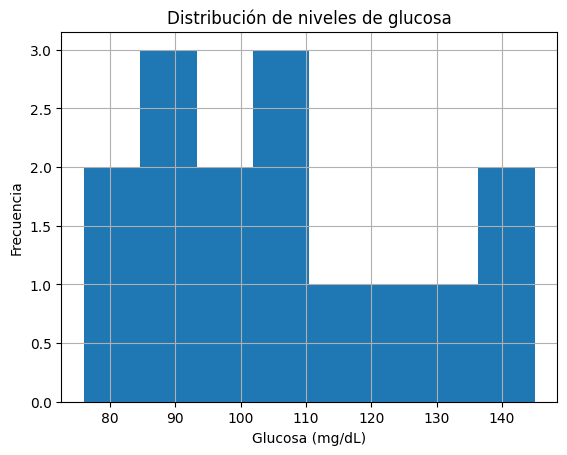

In [8]:
grafica_histograma(glucosa,
                   "Distribución de niveles de glucosa",
                   "Glucosa (mg/dL)")

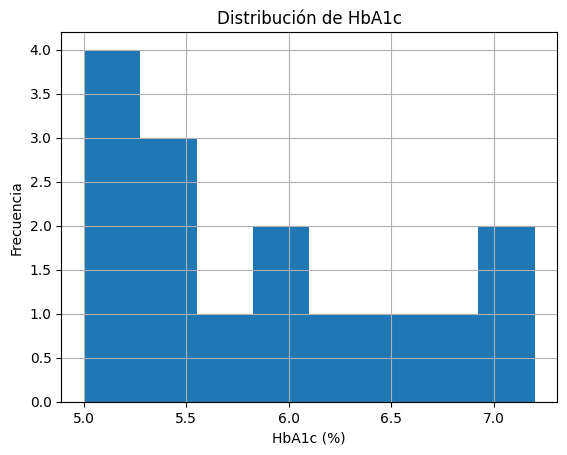

In [6]:
grafica_histograma(hba1c,
                   "Distribución de HbA1c",
                   "HbA1c (%)")

## Parte 4 - Correlación simple

**Calculo de r e interpretación de correlación**

In [89]:
def correlación_simple(x, y):
    n=len(x)

    #Medias
    media_x=sum(x)/n
    media_y=sum(y)/n

    #Sumatorias
    numerador=0
    suma_x=0
    suma_y=0

    for i in range(n):
        dx=x[i]-media_x
        dy=y[i]-media_y

        numerador += dx*dy
        suma_x+=dx**2
        suma_y+=dy**2

    denominador=(suma_x*suma_y)**0.5

    r=numerador/denominador

    #Interpretacion
    if abs(r)>=0.7:
        interpretacion="Fuerte"
    elif abs(r)>=0.4:
        interpretación = "Moderna"
    else:
        interpretación ="Debil"

    return r, interpretacion

In [90]:
print (correlación_simple(glucosa, hba1c))

(0.9926339170142663, 'Fuerte')


## Parte 5 - Reflexión 

*Responder en Markdown:*

**¿Qué ventaja tiene usar funciones?**

Permiten utilizarse distintas veces sin necesidad de estar repetiendo el código, además permite que se entienda mejor al solo tener el nombre y no toda la fórmula, ayuda al orden y si hay algún error solo se corrige una linea.

**¿Qué errores evita?**

Errores de dedo al no tener que repetir constantemente el código, evita que se dificulte modificar el programa, evita que se olvide algún paso al reutilizarlo.

**¿Cómo ayuda en investigación científica?**

Permite dar resultados rapidos y confiables, facilita que los análisis los puedan repetir otros, puede ayudar a estanderizar un método, ayuda al manejo de muchas muestras o abarcar parámetros extensos, reduce los errores humanos y ayuda a organizar análisis.